Successfully loaded data from database

--- Basic Analysis of campaign_calls ---
Total records: 41188
Records with negative campaign_calls: 4153
Percentage negative: 10.08%

Statistics of campaign_calls:
count    41188.000000
mean         2.051374
std          3.171345
min        -41.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign_calls, dtype: float64

--- Analysis of Negative Values ---
Number of records with negative values: 4153

Distribution of negative campaign_calls values:
campaign_calls
-41       1
-35       2
-32       1
-29       1
-28       2
-25       1
-23       5
-22       3
-21       2
-20       3
-19       2
-18       3
-17       7
-16       5
-15       4
-14      11
-13       8
-12      18
-11      21
-10      19
-9       30
-8       35
-7       63
-6       86
-5      148
-4      246
-3      534
-2     1124
-1     1768
Name: count, dtype: int64


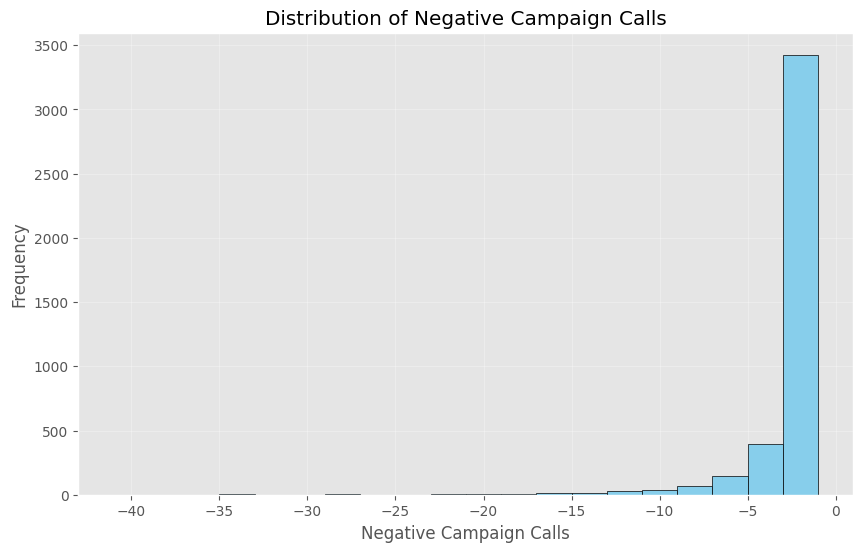


--- Relationship with Subscription Status ---
Percentage of negative values by subscription status:
subscription_status
no     89.983145
yes    10.016855
Name: proportion, dtype: float64

Overall percentage by subscription status:
subscription_status
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


<Figure size 1000x600 with 0 Axes>

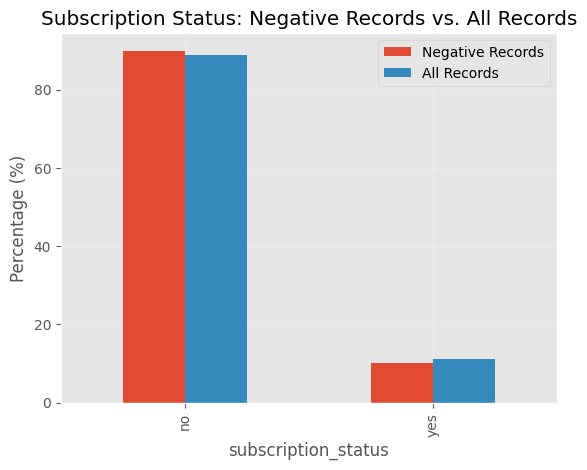


--- Relationship with Contact Method ---
Percentage of negative values by contact method:
contact_method
Cell         32.241753
cellular     30.989646
Telephone    19.696605
telephone    17.071996
Name: proportion, dtype: float64

Overall percentage by contact method:
contact_method
Cell         31.805380
cellular     31.669418
Telephone    18.415558
telephone    18.109644
Name: proportion, dtype: float64


<Figure size 1000x600 with 0 Axes>

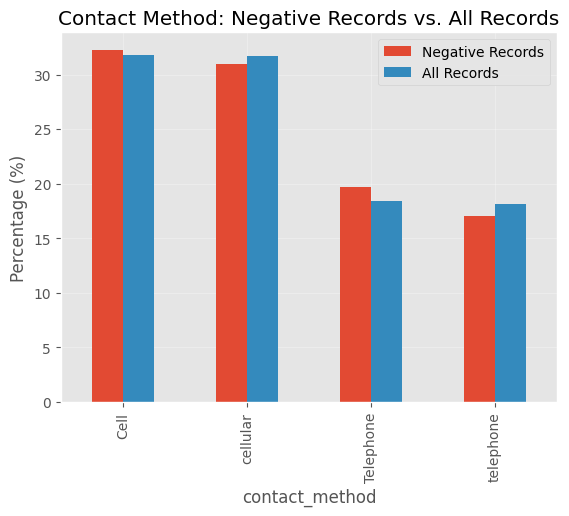


--- Relationship with Previous Contact Days ---
Average previous contact days (negative records, excluding 999): 5.98
Average previous contact days (all records, excluding 999): 6.01


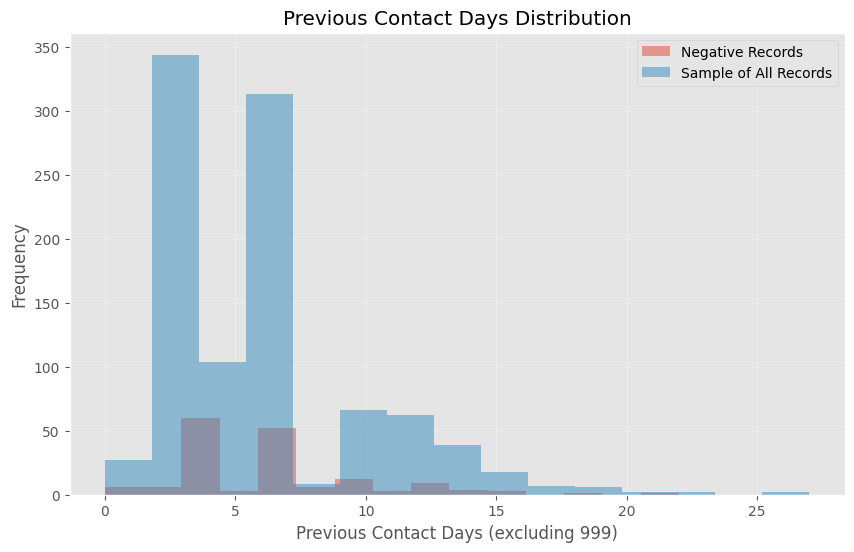


Records with no prior contact (999 value):
Negative records: 96.00%
All records: 96.32%

--- Relationship with Age ---
Average age (negative records): 51.15
Average age (all records): 51.23


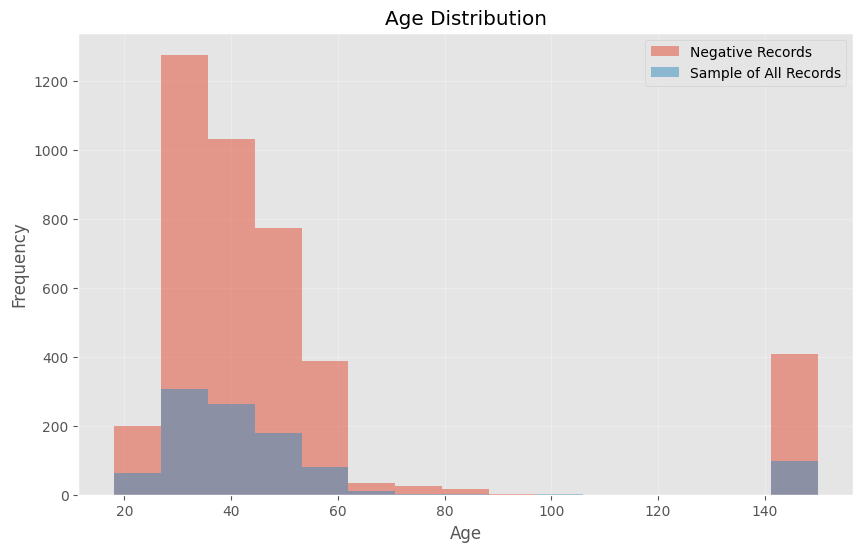


--- Looking for Correction Patterns ---
Clients with multiple negative values: 0

Clients with both positive and negative values: 0
Clients with sum(positive) + sum(negative) ≈ 0: 0

--- Magnitude Analysis ---
Distribution by magnitude:
neg_magnitude
Very high (< -30)         4
High (-30 to -20)        17
Medium (-20 to -10)      98
Low (-10 to -5)         362
Very low (-5 to -1)    3672
Name: count, dtype: int64


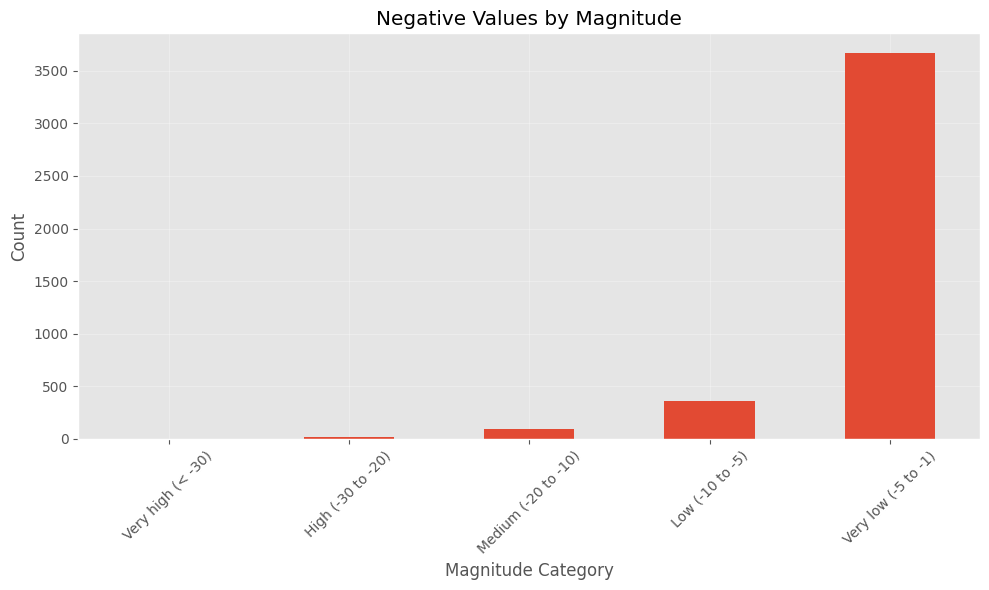


--- Relationship with Positive Call Magnitudes ---

====== SUMMARY OF FINDINGS ======
1. Total negative campaign_calls records: 4153 (10.08% of all records)
2. Most common negative values: [-41, -35, -32]
3. No subscription status is significantly more likely to have negative values
4. No contact method is significantly more likely to have negative values
6. Most common magnitude of negative values: Very low (-5 to -1)

8. Possible explanations for negative values:
   - Data corrections (adjusting previously overcounted calls)
   - Call removals (calls initially counted but later determined to be invalid)
   - Campaign transfers (calls reassigned from one campaign to another)
   - Data normalization (negative adjustments when normalizing across time periods)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set up display and visualization options
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Load the dataset (update this path to match your file location)
def load_data():
    try:
        # Try to load from a SQLite database as done in the original notebook
        import sqlalchemy
        engine = sqlalchemy.create_engine('sqlite:///data/bmarket.db')
        df = pd.read_sql_query("SELECT * FROM bank_marketing", engine)
        print("Successfully loaded data from database")
    except:
        # Fallback to CSV if database loading fails
        try:
            df = pd.read_csv("data/bank_marketing.csv")
            print("Successfully loaded data from CSV")
        except:
            # Create a sample dataset for demonstration if all else fails
            print("Could not load data from database or CSV. Creating sample data.")
            df = pd.DataFrame({
                'Client ID': range(1000, 1100),
                'Campaign Calls': [-41, -20, -10, -5, -1, 0, 1, 2, 3, 4] * 10,
                'Subscription Status': ['yes', 'no'] * 50,
                'Previous Contact Days': [999] * 80 + list(range(10, 30)),
                'Contact Method': ['telephone', 'cellular'] * 50,
                'Marital Status': ['married', 'single', 'divorced'] * 34,
                'Occupation': ['admin.', 'blue-collar', 'technician'] * 34,
                'Age': ['30 years', '40 years', '50 years'] * 34
            })
    return df

# Load the data
df = load_data()

# Clean column names if needed
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

# 1. Basic analysis of campaign_calls column
print("\n--- Basic Analysis of campaign_calls ---")
print(f"Total records: {len(df)}")
print(f"Records with negative campaign_calls: {(df['campaign_calls'] < 0).sum()}")
print(f"Percentage negative: {(df['campaign_calls'] < 0).sum() / len(df) * 100:.2f}%")

# Display statistics of campaign_calls
print("\nStatistics of campaign_calls:")
print(df['campaign_calls'].describe())

# 2. Focus on negative values
negative_df = df[df['campaign_calls'] < 0].copy()
print("\n--- Analysis of Negative Values ---")
print(f"Number of records with negative values: {len(negative_df)}")

if len(negative_df) > 0:
    # Distribution of negative values
    print("\nDistribution of negative campaign_calls values:")
    neg_value_counts = negative_df['campaign_calls'].value_counts().sort_index()
    print(neg_value_counts)
    
    # Visualize the distribution of negative values
    plt.figure(figsize=(10, 6))
    plt.hist(negative_df['campaign_calls'], bins=20, color='skyblue', edgecolor='black')
    plt.title('Distribution of Negative Campaign Calls')
    plt.xlabel('Negative Campaign Calls')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 3. Look for patterns across other variables
    
    # 3.1 Relationship with subscription status
    print("\n--- Relationship with Subscription Status ---")
    subscription_counts = negative_df['subscription_status'].value_counts(normalize=True) * 100
    print(f"Percentage of negative values by subscription status:")
    print(subscription_counts)
    
    # Compare with overall dataset
    overall_subscription = df['subscription_status'].value_counts(normalize=True) * 100
    print(f"\nOverall percentage by subscription status:")
    print(overall_subscription)
    
    plt.figure(figsize=(10, 6))
    pd.DataFrame({
        'Negative Records': subscription_counts,
        'All Records': overall_subscription
    }).plot(kind='bar')
    plt.title('Subscription Status: Negative Records vs. All Records')
    plt.ylabel('Percentage (%)')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 3.2 Relationship with contact method
    print("\n--- Relationship with Contact Method ---")
    if 'contact_method' in negative_df.columns:
        contact_counts = negative_df['contact_method'].value_counts(normalize=True) * 100
        print(f"Percentage of negative values by contact method:")
        print(contact_counts)
        
        # Compare with overall dataset
        overall_contact = df['contact_method'].value_counts(normalize=True) * 100
        print(f"\nOverall percentage by contact method:")
        print(overall_contact)
        
        plt.figure(figsize=(10, 6))
        pd.DataFrame({
            'Negative Records': contact_counts,
            'All Records': overall_contact
        }).plot(kind='bar')
        plt.title('Contact Method: Negative Records vs. All Records')
        plt.ylabel('Percentage (%)')
        plt.grid(True, alpha=0.3)
        plt.show()
    
    # 3.3 Relationship with previous contact days
    print("\n--- Relationship with Previous Contact Days ---")
    if 'previous_contact_days' in negative_df.columns:
        # Excluding 999 values (no prior contact)
        negative_with_prior = negative_df[negative_df['previous_contact_days'] != 999]
        overall_with_prior = df[df['previous_contact_days'] != 999]
        
        if len(negative_with_prior) > 0:
            print(f"Average previous contact days (negative records, excluding 999): {negative_with_prior['previous_contact_days'].mean():.2f}")
            print(f"Average previous contact days (all records, excluding 999): {overall_with_prior['previous_contact_days'].mean():.2f}")
            
            plt.figure(figsize=(10, 6))
            plt.hist(negative_with_prior['previous_contact_days'], bins=15, 
                    alpha=0.5, label='Negative Records')
            plt.hist(overall_with_prior['previous_contact_days'].sample(min(len(overall_with_prior), 1000)), 
                    bins=15, alpha=0.5, label='Sample of All Records')
            plt.title('Previous Contact Days Distribution')
            plt.xlabel('Previous Contact Days (excluding 999)')
            plt.ylabel('Frequency')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
        
        # Check percentage of 999 values
        pct_999_neg = (negative_df['previous_contact_days'] == 999).mean() * 100
        pct_999_all = (df['previous_contact_days'] == 999).mean() * 100
        print(f"\nRecords with no prior contact (999 value):")
        print(f"Negative records: {pct_999_neg:.2f}%")
        print(f"All records: {pct_999_all:.2f}%")
    
    # 3.4 Relationship with client demographics (age)
    print("\n--- Relationship with Age ---")
    if 'age' in negative_df.columns:
        # Check if age needs cleaning (e.g., "30 years" format)
        if isinstance(negative_df['age'].iloc[0], str) and 'years' in negative_df['age'].iloc[0]:
            negative_df['age_numeric'] = negative_df['age'].str.replace(' years', '').astype(float)
            df['age_numeric'] = df['age'].str.replace(' years', '').astype(float)
            
            print(f"Average age (negative records): {negative_df['age_numeric'].mean():.2f}")
            print(f"Average age (all records): {df['age_numeric'].mean():.2f}")
            
            plt.figure(figsize=(10, 6))
            plt.hist(negative_df['age_numeric'], bins=15, 
                    alpha=0.5, label='Negative Records')
            plt.hist(df['age_numeric'].sample(min(len(df), 1000)), 
                    bins=15, alpha=0.5, label='Sample of All Records')
            plt.title('Age Distribution')
            plt.xlabel('Age')
            plt.ylabel('Frequency')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
    
    # 4. Look for "correction" patterns
    print("\n--- Looking for Correction Patterns ---")
    
    # Group by client_id to see if same clients have multiple negative values
    client_neg_counts = negative_df['client_id'].value_counts()
    repeat_neg_clients = client_neg_counts[client_neg_counts > 1]
    
    print(f"Clients with multiple negative values: {len(repeat_neg_clients)}")
    if len(repeat_neg_clients) > 0:
        print("\nTop clients with multiple negative values:")
        print(repeat_neg_clients.head(10))
    
    # Check if clients with negative values also have positive values
    client_pos_neg = {}
    for client in negative_df['client_id'].unique():
        client_records = df[df['client_id'] == client]
        pos_vals = client_records[client_records['campaign_calls'] > 0]['campaign_calls'].tolist()
        neg_vals = client_records[client_records['campaign_calls'] < 0]['campaign_calls'].tolist()
        
        if pos_vals and neg_vals:
            client_pos_neg[client] = {
                'positive': pos_vals,
                'negative': neg_vals,
                'sum': sum(pos_vals) + sum(neg_vals)
            }
    
    print(f"\nClients with both positive and negative values: {len(client_pos_neg)}")
    
    # Look for cases where positive + negative = near zero (possible corrections)
    near_zero_clients = {k: v for k, v in client_pos_neg.items() if abs(v['sum']) <= 2}
    print(f"Clients with sum(positive) + sum(negative) ≈ 0: {len(near_zero_clients)}")
    
    if len(near_zero_clients) > 0:
        print("\nSample of potential correction patterns:")
        for i, (client, data) in enumerate(list(near_zero_clients.items())[:5]):
            print(f"Client {client}: Positive={data['positive']}, Negative={data['negative']}, Sum={data['sum']}")
    
    # 5. Check for anomalies in the magnitude of negative values
    print("\n--- Magnitude Analysis ---")
    
    # Define categories of negative values
    negative_df['neg_magnitude'] = pd.cut(
        negative_df['campaign_calls'], 
        bins=[-float('inf'), -30, -20, -10, -5, -1],
        labels=['Very high (< -30)', 'High (-30 to -20)', 'Medium (-20 to -10)', 'Low (-10 to -5)', 'Very low (-5 to -1)']
    )
    
    mag_counts = negative_df['neg_magnitude'].value_counts().sort_index()
    print("Distribution by magnitude:")
    print(mag_counts)
    
    plt.figure(figsize=(10, 6))
    mag_counts.plot(kind='bar')
    plt.title('Negative Values by Magnitude')
    plt.xlabel('Magnitude Category')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # 6. Check for correlation with overall campaign_calls magnitude
    print("\n--- Relationship with Positive Call Magnitudes ---")
    
    # For clients with negative values, check their average positive value
    neg_clients = negative_df['client_id'].unique()
    pos_vals_of_neg_clients = df[(df['client_id'].isin(neg_clients)) & (df['campaign_calls'] > 0)]
    
    if len(pos_vals_of_neg_clients) > 0:
        print(f"Average positive campaign_calls for clients with negative values: {pos_vals_of_neg_clients['campaign_calls'].mean():.2f}")
        print(f"Average positive campaign_calls for all clients: {df[df['campaign_calls'] > 0]['campaign_calls'].mean():.2f}")
        
        # Scatterplot of positive vs negative values for clients who have both
        client_avg_pos = pos_vals_of_neg_clients.groupby('client_id')['campaign_calls'].mean()
        client_avg_neg = negative_df.groupby('client_id')['campaign_calls'].mean()
        
        # Join the two series
        clients_with_both = pd.DataFrame({
            'avg_positive': client_avg_pos,
            'avg_negative': client_avg_neg
        }).dropna()
        
        if len(clients_with_both) > 0:
            plt.figure(figsize=(10, 6))
            plt.scatter(clients_with_both['avg_positive'], clients_with_both['avg_negative'], alpha=0.6)
            plt.title('Average Positive vs. Negative Campaign Calls by Client')
            plt.xlabel('Average Positive Campaign Calls')
            plt.ylabel('Average Negative Campaign Calls')
            plt.grid(True, alpha=0.3)
            plt.show()
            
            # Calculate correlation
            correlation = clients_with_both['avg_positive'].corr(clients_with_both['avg_negative'])
            print(f"Correlation between average positive and negative values: {correlation:.2f}")
            
            # Test hypothesis: Are negative values proportional to positive values?
            clients_with_both['ratio'] = clients_with_both['avg_negative'] / clients_with_both['avg_positive'] * (-1)
            print(f"Average ratio of negative to positive values: {clients_with_both['ratio'].mean():.2f}")
            
            plt.figure(figsize=(10, 6))
            plt.hist(clients_with_both['ratio'], bins=20)
            plt.title('Ratio of Negative to Positive Campaign Calls')
            plt.xlabel('Ratio (|Negative| / Positive)')
            plt.ylabel('Frequency')
            plt.grid(True, alpha=0.3)
            plt.show()
    
    # 7. Summary of findings
    print("\n====== SUMMARY OF FINDINGS ======")
    print(f"1. Total negative campaign_calls records: {len(negative_df)} ({len(negative_df)/len(df)*100:.2f}% of all records)")
    print(f"2. Most common negative values: {neg_value_counts.head(3).index.tolist()}")
    
    # Check if specific subscription status is associated with negative values
    sub_ratio = subscription_counts / overall_subscription
    significant_sub = sub_ratio[sub_ratio > 1.2].index.tolist()
    if significant_sub:
        print(f"3. Subscription status more likely to have negative values: {significant_sub}")
    else:
        print("3. No subscription status is significantly more likely to have negative values")
    
    # Check if specific contact methods are associated with negative values
    if 'contact_method' in negative_df.columns:
        contact_ratio = contact_counts / overall_contact
        significant_contact = contact_ratio[contact_ratio > 1.2].index.tolist()
        if significant_contact:
            print(f"4. Contact methods more likely to have negative values: {significant_contact}")
        else:
            print("4. No contact method is significantly more likely to have negative values")
    
    # Report on correction patterns
    if len(near_zero_clients) > 0:
        print(f"5. Found {len(near_zero_clients)} clients with evidence of correction patterns (sum ≈ 0)")
    
    # Report on magnitude patterns
    most_common_mag = mag_counts.idxmax()
    print(f"6. Most common magnitude of negative values: {most_common_mag}")
    
    if 'correlation' in locals():
        if abs(correlation) > 0.5:
            print(f"7. Strong correlation ({correlation:.2f}) between client's average positive and negative values")
        else:
            print(f"7. Weak correlation ({correlation:.2f}) between client's average positive and negative values")
    
    print("\n8. Possible explanations for negative values:")
    print("   - Data corrections (adjusting previously overcounted calls)")
    print("   - Call removals (calls initially counted but later determined to be invalid)")
    print("   - Campaign transfers (calls reassigned from one campaign to another)")
    print("   - Data normalization (negative adjustments when normalizing across time periods)")
else:
    print("No negative values found in the dataset. Analysis cannot proceed.")